In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the stock prices you already downloaded
prices = pd.read_csv(
    "five_stock_prices.csv",
    index_col=0,
    parse_dates=True
)

prices = prices.sort_index()

# Start with Apple
stock = prices["AAPL"].dropna()

print("Trading days:", len(stock))
display(stock.head())

Trading days: 250


Date
2025-09-23    253.493591
2025-09-24    251.381409
2025-09-25    255.924637
2025-09-26    254.519806
2025-09-29    253.493591
Name: AAPL, dtype: float64

In [2]:

strategy = pd.DataFrame(index=stock.index)
strategy["price"] = stock

strategy["SMA20"] = stock.rolling(20).mean()
strategy["SMA50"] = stock.rolling(50).mean()

strategy["signal"] = (
    strategy["SMA20"] > strategy["SMA50"]
).astype(int)

# Shift to avoid using today's closing price
# to earn today's return
strategy["position"] = strategy["signal"].shift(1).fillna(0)

display(strategy.tail(10))

,price,SMA20,SMA50,signal,position
Date,,,,,
2026-09-08,316.220001,313.537999,315.641459,0,0.0
2026-09-09,315.339996,314.059499,316.318314,0,0.0
2026-09-10,326.570007,315.275499,317.067501,0,0.0
2026-09-11,332.269989,316.625998,317.830374,0,0.0
2026-09-14,333.079987,317.983498,318.324693,0,0.0
2026-09-15,331.339996,319.270998,318.703681,1,0.0
2026-09-16,332.410004,320.389998,319.144035,1,1.0
2026-09-17,337.000000,321.398499,319.621636,1,1.0
2026-09-18,336.130005,322.639999,320.025286,1,1.0


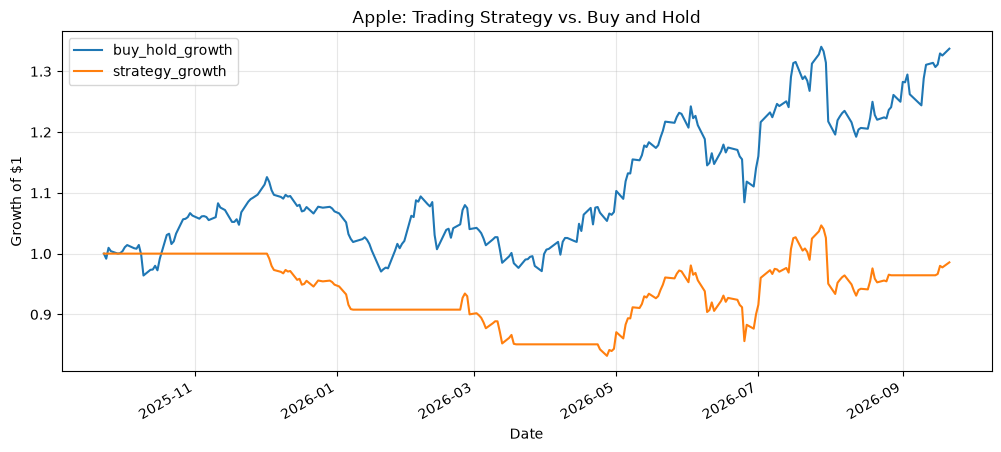

In [3]:

transaction_cost = 0.001  # 0.10% per trade

strategy["stock_return"] = stock.pct_change().fillna(0)

strategy["trades"] = (
    strategy["position"].diff().abs().fillna(0)
)

strategy["strategy_return"] = (
    strategy["position"] * strategy["stock_return"]
    - strategy["trades"] * transaction_cost
)

strategy["buy_hold_growth"] = (
    1 + strategy["stock_return"]
).cumprod()

strategy["strategy_growth"] = (
    1 + strategy["strategy_return"]
).cumprod()

strategy[["buy_hold_growth", "strategy_growth"]].plot(
    figsize=(12, 5),
    title="Apple: Trading Strategy vs. Buy and Hold"
)

plt.ylabel("Growth of $1")
plt.grid(alpha=0.3)
plt.show()

In [4]:

# Day 9: Trading strategy performance report

def performance_metrics(returns):
    returns = returns.dropna()

    total_return = (1 + returns).prod() - 1
    annual_return = (1 + total_return) ** (252 / len(returns)) - 1
    volatility = returns.std() * np.sqrt(252)

    risk_free_rate = 0.04
    sharpe = (
        (annual_return - risk_free_rate) / volatility
        if volatility > 0 else np.nan
    )

    growth = (1 + returns).cumprod()
    drawdown = growth / growth.cummax() - 1

    return {
        "Total Return": f"{total_return:.2%}",
        "Annualized Return": f"{annual_return:.2%}",
        "Annualized Volatility": f"{volatility:.2%}",
        "Sharpe Ratio": round(sharpe, 2),
        "Maximum Drawdown": f"{drawdown.min():.2%}"
    }

report = pd.DataFrame({
    "Trading Strategy": performance_metrics(
        strategy["strategy_return"]
    ),
    "Buy and Hold": performance_metrics(
        strategy["stock_return"]
    )
})

display(report)

print("Number of trades:", int(strategy["trades"].sum()))

,Trading Strategy,Buy and Hold
Total Return,-1.44%,33.72%
Annualized Return,-1.45%,34.03%
Annualized Volatility,18.49%,24.54%
Sharpe Ratio,-0.29,1.22
Maximum Drawdown,-16.82%,-13.80%


Number of trades: 9


In [5]:

# Inspect strategy signals and trade dates

print("Available columns:")
print(strategy.columns.tolist())

# Display rows where the trading position changes
if "position" in strategy.columns:
    trades = strategy.loc[
        strategy["position"].diff().fillna(0) != 0
    ].copy()

    display(trades)
    print("Position changes:", len(trades))

Available columns:
['price', 'SMA20', 'SMA50', 'signal', 'position', 'stock_return', 'trades', 'strategy_return', 'buy_hold_growth', 'strategy_growth']


,price,SMA20,SMA50,signal,position,stock_return,trades,strategy_return,buy_hold_growth,strategy_growth
Date,,,,,,,,,,
2025-12-03,283.378662,273.008739,263.704372,1,1.0,-0.007128,1.0,-0.008128,1.117893,0.991872
2026-01-08,258.336823,270.800391,272.026128,0,0.0,-0.004955,1.0,-0.001000,1.019106,0.907815
2026-02-24,271.655243,266.187675,265.093118,1,1.0,0.022391,1.0,0.021391,1.071645,0.927235
2026-03-19,248.516525,260.352882,260.804387,0,0.0,-0.003921,1.0,-0.001000,0.980366,0.850743
2026-04-24,270.577118,260.932842,259.681979,1,1.0,-0.008668,1.0,-0.009668,1.067392,0.842518
2026-07-09,315.947510,296.660147,296.574000,1,0.0,0.009030,1.0,-0.001000,1.246373,0.974013
2026-07-10,315.048309,297.846126,297.470411,1,1.0,-0.002846,1.0,-0.003846,1.242826,0.970267
2026-08-27,314.579987,309.241431,311.331147,0,0.0,0.003605,1.0,-0.001000,1.240978,0.964379
2026-09-16,332.410004,320.389998,319.144035,1,1.0,0.003229,1.0,0.002229,1.311315,0.966529


Position changes: 9


In [6]:

# Diagnose the strategy's performance

# Identify days the strategy was invested or in cash
invested = strategy["position"].shift(1).fillna(0) == 1
in_cash = ~invested

# Compare Apple's returns during both periods
diagnosis = pd.DataFrame({
    "Metric": [
        "Days invested",
        "Days in cash",
        "Apple return while invested",
        "Apple return while in cash",
        "Strategy total return",
        "Buy-and-hold total return"
    ],
    "Value": [
        int(invested.sum()),
        int(in_cash.sum()),
        f"{((1 + strategy.loc[invested, 'stock_return']).prod() - 1):.2%}",
        f"{((1 + strategy.loc[in_cash, 'stock_return']).prod() - 1):.2%}",
        f"{((1 + strategy['strategy_return']).prod() - 1):.2%}",
        f"{((1 + strategy['stock_return']).prod() - 1):.2%}"
    ]
})

display(diagnosis)

,Metric,Value
0,Days invested,129
1,Days in cash,121
2,Apple return while invested,-0.84%
3,Apple return while in cash,34.86%
4,Strategy total return,-1.44%
5,Buy-and-hold total return,33.72%


In [7]:

# Day 9: Trade-by-trade performance
# Uses yesterday's signal as today's actual position

data = strategy.copy()
data["actual_position"] = (
    data["position"].shift(1).fillna(0).astype(int)
)

data["trade_change"] = data["actual_position"].diff().fillna(
    data["actual_position"]
)

# Each continuous invested period is one trade
data["trade_id"] = (data["trade_change"] == 1).cumsum()

invested_days = data[data["actual_position"] == 1].copy()

trade_log = invested_days.groupby("trade_id").agg(
    entry_date=("actual_position", lambda x: x.index.min()),
    last_invested_date=("actual_position", lambda x: x.index.max()),
    holding_days=("stock_return", "count"),
    gross_return=("stock_return",
                  lambda x: (1 + x).prod() - 1)
)

trade_log["gross_return_pct"] = (
    trade_log["gross_return"] * 100
).round(2)

display(
    trade_log[
        ["entry_date", "last_invested_date",
         "holding_days", "gross_return_pct"]
    ]
)

print("Completed and open trade periods:", len(trade_log))
print(
    "Profitable periods:",
    int((trade_log["gross_return"] > 0).sum())
)

,entry_date,last_invested_date,holding_days,gross_return_pct
trade_id,,,,
1,2025-12-04,2026-01-08,24,-8.84
2,2026-02-25,2026-03-19,17,-8.52
3,2026-04-27,2026-07-09,51,16.77
4,2026-07-13,2026-08-27,34,-0.15
5,2026-09-17,2026-09-21,3,1.98


Completed and open trade periods: 5
Profitable periods: 2


,Total Return,"Final Value ($10,000)"
No costs,-0.84%,"$9,915.95"
0.05% per transaction,-1.29%,"$9,871.43"
0.10% per transaction,-1.73%,"$9,827.08"
0.20% per transaction,-2.61%,"$9,738.93"


Position changes: 9


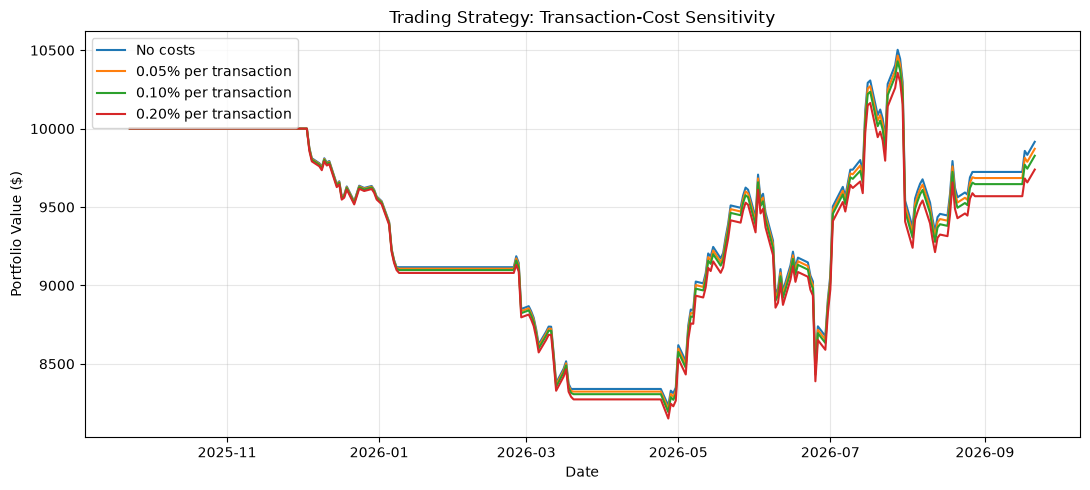

In [8]:

# Day 9: Transaction-cost sensitivity

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

test = strategy.copy()

# Yesterday's signal determines today's exposure
test["actual_position"] = (
    test["position"].shift(1).fillna(0)
)

# Count entries and exits, including the initial entry
test["turnover"] = (
    test["actual_position"].diff()
    .fillna(test["actual_position"])
    .abs()
)

# Rebuild gross returns before trading costs
test["gross_return"] = (
    test["actual_position"] * test["stock_return"]
)

cost_levels = {
    "No costs": 0,
    "0.05% per transaction": 0.0005,
    "0.10% per transaction": 0.001,
    "0.20% per transaction": 0.002
}

results = {}

for name, cost in cost_levels.items():
    net_return = (
        test["gross_return"]
        - test["turnover"] * cost
    )

    results[name] = {
        "Total Return": (1 + net_return).prod() - 1,
        "Final Value ($10,000)": 10000 * (1 + net_return).prod()
    }

cost_report = pd.DataFrame(results).T

display(
    cost_report.style.format({
        "Total Return": "{:.2%}",
        "Final Value ($10,000)": "${:,.2f}"
    })
)

print("Position changes:", int(test["turnover"].sum()))

# Compare cumulative portfolio growth
plt.figure(figsize=(11, 5))

for name, cost in cost_levels.items():
    net_return = test["gross_return"] - test["turnover"] * cost
    growth = 10000 * (1 + net_return).cumprod()
    plt.plot(test.index, growth, label=name)

plt.title("Trading Strategy: Transaction-Cost Sensitivity")
plt.ylabel("Portfolio Value ($)")
plt.xlabel("Date")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Day 9 — Apple Trading Strategy: Research Conclusion

**Objective:** Evaluate a rule-based Apple trading strategy against a buy-and-hold benchmark using historical prices.

**Key findings**

* The strategy generated a −1.44% return, compared with +33.72% for buy-and-hold in the original backtest.
* It was invested for 129 trading days and held cash for 121 days.
* Apple gained 34.86% during the strategy's cash periods, indicating that missed market exposure was a major source of underperformance.
* Five invested periods were identified, of which two were profitable. The final period remained open.
* Transaction-cost sensitivity was tested at 0%, 0.05%, 0.10% and 0.20% per position change.

**Conclusion:** The strategy's historical entry and exit signals did not capture Apple's major gains. Lower volatility alone did not produce better risk-adjusted performance.

**Limitations:** Results depend on the historical sample, execution timing, assumed transaction costs and trading rules. Further testing should include different market regimes and out-of-sample data.
